  <h2>Hi, i'm junaid, This project is based on chennai's water woes.</h2>

<h3> Chennai, also known as Madras, is one of the four metro cities of India. Located on the coromondal coast, Chennai is majorly dependent on ground water resources to meet its water needs. However, Growing development and setting up of new industries in recent years, especially in southern Chennai, has taken its toll on ground water level . Currently, Chennai is facing an acute water shortage due to shortage of rainfall for the past three years (and we had one of the worst floods in history the year before that!). As a result, the water in these resources are depleting along with the groundwater level. The wetlands, once reponsible for ground water recharge, have now disappeared. We'll analyse the data of water level of major reservoir - Red Hills, Cholavaram, Poondi and Chembarambakkam - and try to understand and verify claims on decreasing water level.    </h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/home/junaid/Downloads/chennai_reservoir_levels.csv")
df

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
0,01-01-2004,3.9,0.0,268.0,0.0
1,02-01-2004,3.9,0.0,268.0,0.0
2,03-01-2004,3.9,0.0,267.0,0.0
3,04-01-2004,3.9,0.0,267.0,0.0
4,05-01-2004,3.8,0.0,267.0,0.0
...,...,...,...,...,...
5642,13-06-2019,30.0,0.0,0.0,1.0
5643,14-06-2019,28.0,0.0,0.0,1.0
5644,15-06-2019,27.0,0.0,0.0,1.0
5645,16-06-2019,26.0,0.0,0.0,1.0


<h3> Summery of DataFrame.</h3>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             5647 non-null   object 
 1   POONDI           5647 non-null   float64
 2   CHOLAVARAM       5647 non-null   float64
 3   REDHILLS         5647 non-null   float64
 4   CHEMBARAMBAKKAM  5647 non-null   float64
dtypes: float64(4), object(1)
memory usage: 220.7+ KB


In [70]:
df['Date']
type(df['Date'][0])

pandas._libs.tslibs.timestamps.Timestamp

<h2> Here the type of  'Date' column is object , lets convert 'date'column into datetime format for easier data-based operations like filtring, grouping or sorting</h2>

In [5]:
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             5647 non-null   datetime64[ns]
 1   POONDI           5647 non-null   float64       
 2   CHOLAVARAM       5647 non-null   float64       
 3   REDHILLS         5647 non-null   float64       
 4   CHEMBARAMBAKKAM  5647 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 220.7 KB


In [6]:
df.columns

Index(['Date', 'POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM'], dtype='object')

<h2>Calculate total by summing values across location columns </h2>

In [7]:
df['total']=df[['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']].sum(axis=1)

df.head()

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,total
0,2004-01-01,3.9,0.0,268.0,0.0,271.9
1,2004-01-02,3.9,0.0,268.0,0.0,271.9
2,2004-01-03,3.9,0.0,267.0,0.0,270.9
3,2004-01-04,3.9,0.0,267.0,0.0,270.9
4,2004-01-05,3.8,0.0,267.0,0.0,270.8


<h2> Extract year and month from 'date' column for further analysis </h2>

In [8]:
df['year']=df['Date'].apply(lambda x : x.year)
df['Month']=df['Date'].apply(lambda x : x.month)
df.head()

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,total,year,Month
0,2004-01-01,3.9,0.0,268.0,0.0,271.9,2004,1
1,2004-01-02,3.9,0.0,268.0,0.0,271.9,2004,1
2,2004-01-03,3.9,0.0,267.0,0.0,270.9,2004,1
3,2004-01-04,3.9,0.0,267.0,0.0,270.9,2004,1
4,2004-01-05,3.8,0.0,267.0,0.0,270.8,2004,1


<h2> Calculate yearly averages for each column ,keeping 'year' as a column </h2>

In [25]:
yearwise=df.groupby('year', as_index=False).mean()
yearwise

,year,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,total,Month
0,2004,2004-07-01 12:00:00,77.766967,19.060109,220.899180,68.683060,386.409317,6.513661
1,2005,2005-07-02 00:00:00,722.680603,147.771781,1468.480712,581.345205,2920.278301,6.526027
2,2006,2006-07-02 00:00:00,1827.553425,484.947945,2044.356164,2075.317808,6432.175342,6.526027
3,2007,2007-07-02 00:00:00,1794.912329,286.391781,2356.654795,1715.126027,6153.084932,6.526027
4,2008,2008-07-01 12:00:00,1862.338798,545.609290,2445.161202,2196.967213,7050.076503,6.513661
5,2009,2009-07-02 00:00:00,1846.221918,414.882110,1969.731205,1795.677123,6026.512356,6.526027
6,2010,2010-07-02 00:00:00,1651.523288,382.175342,2045.271233,2020.501370,6099.471233,6.526027
7,2011,2011-07-02 00:00:00,2399.068493,499.509589,2573.326027,2492.282192,7964.186301,6.526027
8,2012,2012-07-01 12:00:00,1742.816940,225.934426,1872.218579,1571.677596,5412.647541,6.513661
9,2013,2013-07-02 00:00:00,536.953425,100.049315,1324.109589,988.964384,2950.076712,6.526027


In [29]:
yearwise=yearwise[['year','POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM','total']]
yearwise

,year,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,total
0,2004,77.766967,19.060109,220.899180,68.683060,386.409317
1,2005,722.680603,147.771781,1468.480712,581.345205,2920.278301
2,2006,1827.553425,484.947945,2044.356164,2075.317808,6432.175342
3,2007,1794.912329,286.391781,2356.654795,1715.126027,6153.084932
4,2008,1862.338798,545.609290,2445.161202,2196.967213,7050.076503
5,2009,1846.221918,414.882110,1969.731205,1795.677123,6026.512356
6,2010,1651.523288,382.175342,2045.271233,2020.501370,6099.471233
7,2011,2399.068493,499.509589,2573.326027,2492.282192,7964.186301
8,2012,1742.816940,225.934426,1872.218579,1571.677596,5412.647541
9,2013,536.953425,100.049315,1324.109589,988.964384,2950.076712


<h2> plot a bar chart of men yearly levels in all four reservoirs, x-axis represents the year and y- axis represents the total level.</h2>

/tmp/ipykernel_12959/3274799175.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year',y='total',data=yearwise,palette='Set2' ,legend=False)


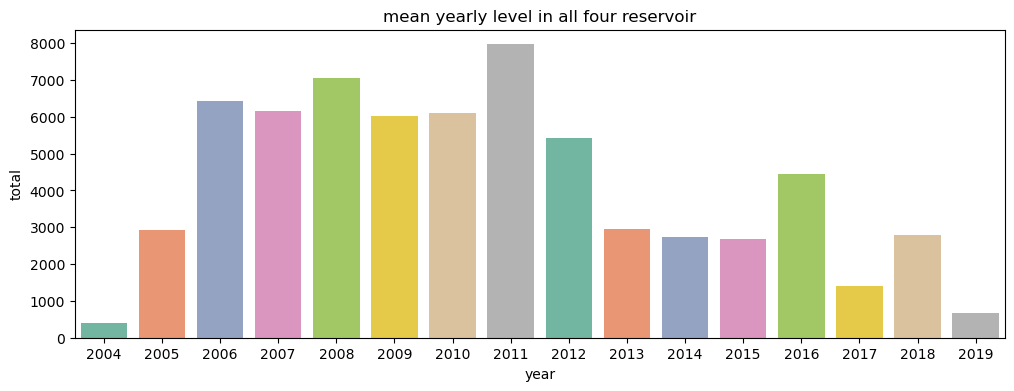

In [77]:
plt.figure(figsize=(12,4))
sns.barplot(x='year',y='total',data=yearwise,palette='Set2' ,legend=False)
plt.title("mean yearly level in all four reservoir")
plt.show()

<h2> plot yearly data for reservoirs</h2>

<Axes: xlabel='year'>

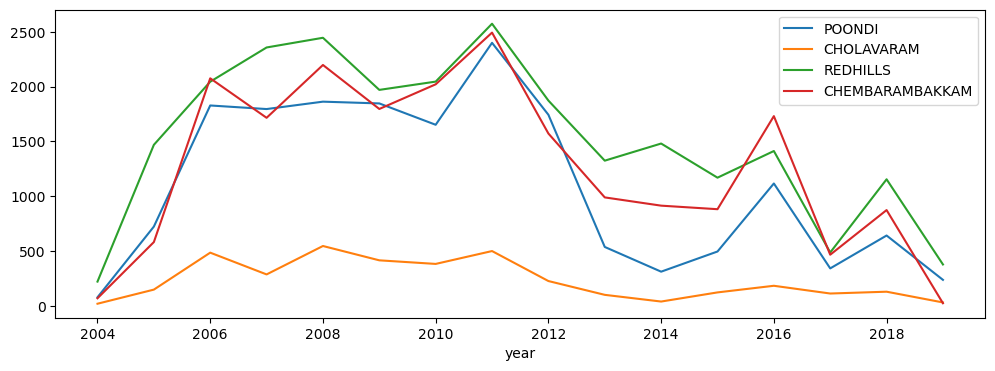

In [40]:
yearwise.plot(x='year',y=['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM'],figsize=(12,4))

<h2> convert 'month' and 'year' columns to categorical type for memory efficiency and to  enable categorical operatrions</h2>

In [47]:
df['Month']=pd.Categorical(df['Month'])
df['year']=pd.Categorical(df['year'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             5647 non-null   datetime64[ns]
 1   POONDI           5647 non-null   float64       
 2   CHOLAVARAM       5647 non-null   float64       
 3   REDHILLS         5647 non-null   float64       
 4   CHEMBARAMBAKKAM  5647 non-null   float64       
 5   total            5647 non-null   float64       
 6   year             5647 non-null   category      
 7   Month            5647 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(5)
memory usage: 276.9 KB


<h2> Create a bar plot to visualize 'total' by 'year' with bars colored by 'month'</h2>

<Axes: xlabel='year', ylabel='total'>

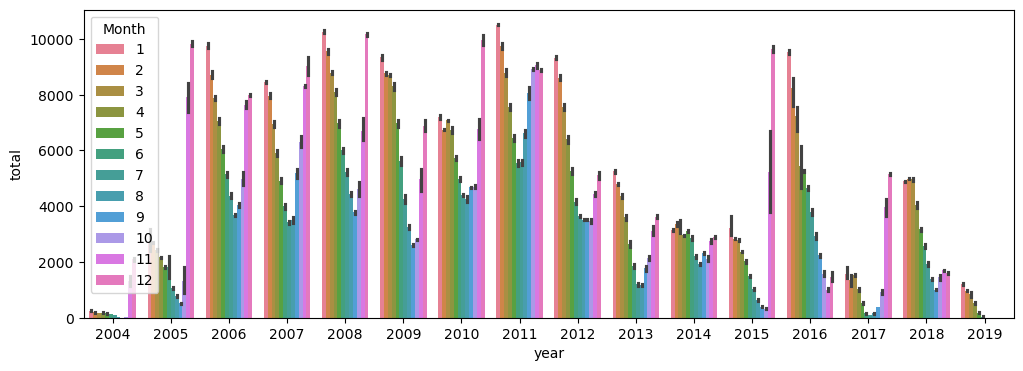

In [52]:
plt.figure(figsize=(12,4))
sns.barplot(x='year',y='total',data=df,hue='Month')

<h3>Inferences:

a. Chennai gets some rains in the month of June, July, August and September due to south west monsoon. b. But Majority of rainfall happens during October and November, due to North-east monsoon. c. During the initial years rain from north-east monsoon is much higher than south-west monsoon. However, In last few years, both South Westand North-East monsoon are contributing equally. d. Declining North-East monsoon in recent years go in line with the declining rainfall in Meghalaya, which also depends on North-East monsoon.

Now, let's explore the availability of water at the start of the summer (january) and end of the year (december)</h3>



/tmp/ipykernel_12959/4154463160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year',y='total',data=jan,palette='Set2',color="red")


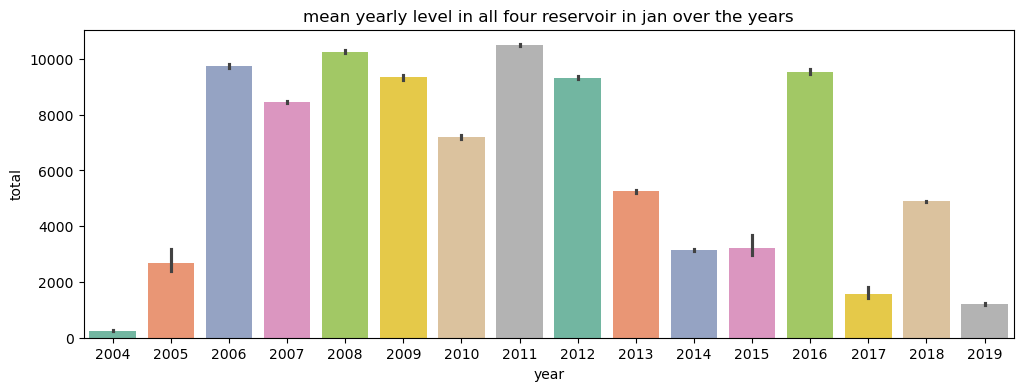

In [59]:
jan=df[df['Month']==1]
plt.figure(figsize=(12,4))
sns.barplot(x='year',y='total',data=jan,palette='Set2')
plt.title("mean yearly level in all four reservoir in jan over the years")
plt.show()

/tmp/ipykernel_12959/1896633916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year',y='total',data=dec,palette='Set2')


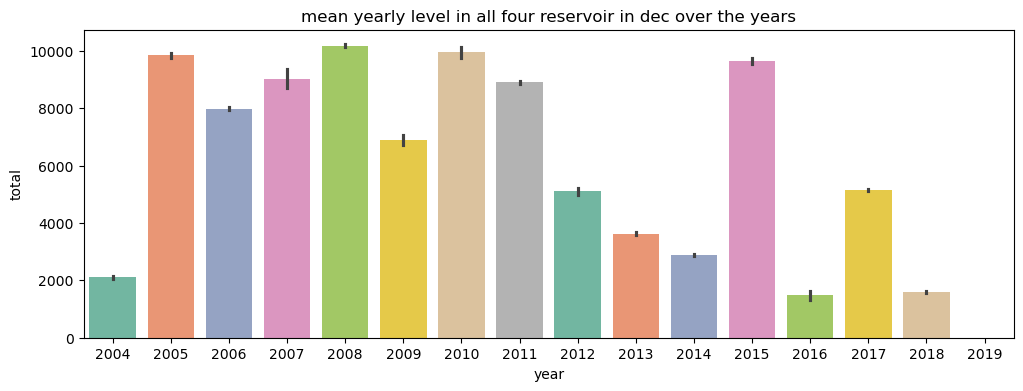

In [56]:
dec=df[df['Month']==12]
plt.figure(figsize=(12,4))
sns.barplot(x='year',y='total',data=dec,palette='Set2')
plt.title("mean yearly level in all four reservoir in dec over the years")
plt.show()

<h3> This clearly indicates that there is not enough water in the reservoirs at the beginning of summer 2019 to cope up with the needs of the city. Infact this is at the second worst level after 2004. Bar few exceptions, the declining trend is clearly noticeable since 2011. As population as grown multiple times since 2004, water resources in 2019 is at the most critical stage.

However, Damage was being done when huge infrastructures took place of wetlands, near Kelambakkam area of South Chennai.

These are just repercussions....!!</h3>